In [10]:
%matplotlib inline
import os, sys, glob, numpy as np, matplotlib.pyplot as plt
import cv2
import mediapipe as mp

print("Python:", sys.version.split()[0])
print("numpy:", np.__version__)
print("opencv:", cv2.__version__)


Python: 3.9.24
numpy: 1.26.4
opencv: 4.9.0


In [11]:
# Base (no extension given)
BASE = r"C:\Users\islam\SportsPose\data\data\photos\IMG_7969"

# Try to resolve the actual file (handles .jpg/.jpeg/.png/.heic)
SEARCH_EXTS = [".jpg", ".jpeg", ".png", ".heic", ".JPG", ".JPEG", ".PNG", ".HEIC"]
candidates = [p for ext in SEARCH_EXTS for p in glob.glob(BASE + ext)]
IMG_PATH = candidates[0] if candidates else BASE  # fall back to BASE as-is

OUT_DIR = r"C:\Users\islam\SportsPose\results\"
os.makedirs(OUT_DIR, exist_ok=True)

print("Resolved IMG_PATH:", IMG_PATH)


Resolved IMG_PATH: C:\Users\islam\SportsPose\data\data\photos\IMG_7969.png


In [28]:
# If you haven't yet:
# !pip install ultralytics opencv-python matplotlib numpy

from ultralytics import YOLO
import cv2, numpy as np, matplotlib.pyplot as plt
import glob, os

# --- auto-resolve the real file (handles .jpg/.jpeg/.png/.heic) ---
BASE = r"C:\Users\islam\SportsPose\data\data\photos\IMG_7969"
CAND_EXTS = [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG", ".heic", ".HEIC"]
cands = [BASE + ext for ext in CAND_EXTS if os.path.exists(BASE + ext)]
IMG_PATH = cands[0] if cands else BASE  # if you actually typed full name already

print("IMG_PATH =>", IMG_PATH)
assert os.path.exists(IMG_PATH), f"File not found: {IMG_PATH}"

# HEIC -> convert via PIL if OpenCV can't read it
img = cv2.imread(IMG_PATH)
if img is None and IMG_PATH.lower().endswith(".heic"):
    try:
        from PIL import Image
        import pillow_heif
        pillow_heif.register_heif_opener()
        img = cv2.cvtColor(np.array(Image.open(IMG_PATH).convert("RGB")), cv2.COLOR_RGB2BGR)
    except Exception as e:
        raise AssertionError(f"HEIC read failed; install pillow & pillow-heif or export JPG/PNG. Error: {e}")
assert img is not None, "Could not read image (check path/extension)."

# --- run YOLOv8 pose (multi-person 2D) ---
model = YOLO("yolov8s-pose.pt")
res = model(img)[0]
poses = res.keypoints.xy.cpu().numpy()  # (n_person, 17, 2)
print("persons detected:", len(poses))

# --- draw COCO-17 skeleton (explicit edges, avoids model-specific attr) ---
COCO_EDGES = [
    (5,7),(7,9),    # left arm: shoulder->elbow->wrist
    (6,8),(8,10),   # right arm
    (5,6),          # shoulders
    (11,12),        # hips
    (5,11),(6,12),  # torso
    (11,13),(13,15),# left leg: hip->knee->ankle
    (12,14),(14,16) # right leg
]

overlay = img.copy()
for p in poses:
    for x,y in p.astype(int):
        cv2.circle(overlay, (x,y), 3, (0,255,0), -1)
    for a,b in COCO_EDGES:
        pa, pb = p[a].astype(int), p[b].astype(int)
        cv2.line(overlay, tuple(pa), tuple(pb), (255,0,0), 2)

plt.figure(figsize=(8,5))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Multi-person 2D Skeletons")
plt.axis("off")
plt.show()
out2d_path = os.path.join(OUT_DIR, "IMG_2D_skeleton.jpg")

# Convert BGR->RGB for saving with matplotlib
plt.figure(figsize=(8,5))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.tight_layout()
plt.savefig(out2d_path, dpi=300, bbox_inches="tight")
plt.close()

print("Saved 2D skeleton image to:", out2d_path)

IMG_PATH => C:\Users\islam\SportsPose\data\data\photos\IMG_7969.png

0: 448x640 2 persons, 558.8ms
Speed: 786.4ms preprocess, 558.8ms inference, 34.0ms postprocess per image at shape (1, 3, 448, 640)
persons detected: 2


<Figure size 800x500 with 1 Axes>

Saved 2D skeleton image to: C:\Users\islam\SportsPose\results\IMG_2D_skeleton.jpg


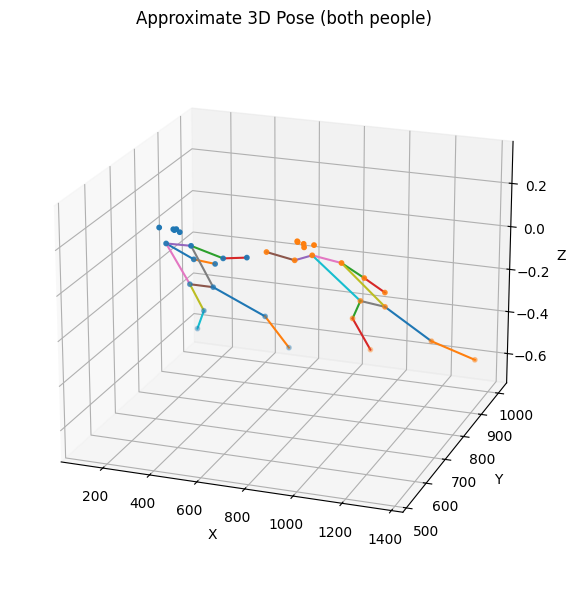

Saved 3D pose image to: C:\Users\islam\SportsPose\results\IMG_3D_pose.jpg


In [13]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np

def fake_lift(p2d):
    # crude depth from vertical position (for visualization only)
    z = -0.002 * (p2d[:,1] - np.mean(p2d[:,1]))
    return np.c_[p2d, z]

assert 'poses' in globals(), "Run the previous cell first so 'poses' is defined."

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection="3d")

for p in poses:
    p3d = fake_lift(p)
    # draw edges
    for a,b in [(5,7),(7,9),(6,8),(8,10),(5,6),(11,12),(5,11),(6,12),(11,13),(13,15),(12,14),(14,16)]:
        ax.plot([p3d[a,0], p3d[b,0]],[p3d[a,1], p3d[b,1]],[p3d[a,2], p3d[b,2]])
    ax.scatter(p3d[:,0], p3d[:,1], p3d[:,2], s=10)

ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title("Approximate 3D Pose (both people)")
ax.view_init(20, -70)
save_path = os.path.join(OUT_DIR, "IMG_graph.jpg")
plt.tight_layout(); plt.show()

out3d_path = os.path.join(OUT_DIR, "IMG_3D_pose.jpg")

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection="3d")

for p in poses:
    p3d = fake_lift(p)
    for a,b in [(5,7),(7,9),(6,8),(8,10),(5,6),(11,12),(5,11),(6,12),(11,13),(13,15),(12,14),(14,16)]:
        ax.plot([p3d[a,0], p3d[b,0]],
                [p3d[a,1], p3d[b,1]],
                [p3d[a,2], p3d[b,2]])
    ax.scatter(p3d[:,0], p3d[:,1], p3d[:,2], s=10)

ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.view_init(20, -70)

plt.tight_layout()
plt.savefig(out3d_path, dpi=300, bbox_inches="tight")
plt.close()

print("Saved 3D pose image to:", out3d_path)


In [14]:
import os
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import cv2
import numpy as np

# Output video path
vid_path = os.path.join(OUT_DIR, "IMG_3D_rotate.mp4")
print("Saving 3D rotation video to:", vid_path)

# Video settings
W, H = 800, 800        # frame size in pixels
fps = 20               # frames per second
n_frames = 120         # number of frames in the rotation

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
vw = cv2.VideoWriter(vid_path, fourcc, fps, (W, H))

# Edges (same as before)
EDGES_3D = [(5,7),(7,9),
            (6,8),(8,10),
            (5,6),
            (11,12),
            (5,11),(6,12),
            (11,13),(13,15),
            (12,14),(14,16)]

def render_frame(azim):
    """Render a single 3D frame at a given azimuth, return as BGR uint8 image."""
    fig = Figure(figsize=(W/100, H/100), dpi=100)
    canvas = FigureCanvas(fig)
    ax = fig.add_subplot(111, projection="3d")

    for p in poses:
        p3d = fake_lift(p)
        # draw edges
        for a, b in EDGES_3D:
            ax.plot(
                [p3d[a,0], p3d[b,0]],
                [p3d[a,1], p3d[b,1]],
                [p3d[a,2], p3d[b,2]]
            )
        ax.scatter(p3d[:,0], p3d[:,1], p3d[:,2], s=10)

    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.view_init(elev=20, azim=azim)

    # Keep axes tight around data
    ax.set_box_aspect([1,1,1])

    fig.tight_layout()
    canvas.draw()

    # Convert canvas to an image (RGB) then BGR for OpenCV
    frame = np.frombuffer(canvas.tostring_rgb(), dtype=np.uint8)
    frame = frame.reshape(H, W, 3)
    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    return frame_bgr

# Generate rotation frames
for i in range(n_frames):
    az = -70 + 360.0 * i / n_frames   # start at -70 deg, rotate full circle
    frame_bgr = render_frame(az)
    vw.write(frame_bgr)

vw.release()
print("Done. Video saved:", vid_path)


Saving 3D rotation video to: C:\Users\islam\SportsPose\results\IMG_3D_rotate.mp4


C:\Users\islam\AppData\Local\Temp\ipykernel_81524\4143370333.py:55: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  frame = np.frombuffer(canvas.tostring_rgb(), dtype=np.uint8)


Done. Video saved: C:\Users\islam\SportsPose\results\IMG_3D_rotate.mp4


In [22]:
import pandas as pd
import os
import numpy as np

# Make sure YOLO cell ran
assert 'poses' in globals(), "Run the YOLO pose detection cell first."
assert 'OUT_DIR' in globals(), "OUT_DIR must be defined (your results folder)."

# Create new output folder
OUTPUT_DIR = os.path.join(OUT_DIR, "outputCOCO17")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Joint names for YOLOv8 / COCO-17 order
JOINT_NAMES = [
    "nose","left_eye","right_eye","left_ear","right_ear",
    "left_shoulder","right_shoulder","left_elbow","right_elbow",
    "left_wrist","right_wrist","left_hip","right_hip",
    "left_knee","right_knee","left_ankle","right_ankle"
]

# Build dict of DataFrames (one sheet per person)
sheet_dict = {}

for person_id, p2d in enumerate(poses):   # p2d shape: (17, 2)

    rows = []
    for j in range(17):
        x, y = p2d[j]
        rows.append({
            "joint_index": j,
            "joint_name": JOINT_NAMES[j],
            "x_px": float(x),
            "y_px": float(y)
        })

    df_person = pd.DataFrame(rows)
    sheet_name = f"person_{person_id + 1}"
    sheet_dict[sheet_name] = df_person

# Write to Excel
excel_path = os.path.join(OUTPUT_DIR, "pose_coordinates_2D_real.xlsx")
with pd.ExcelWriter(excel_path) as writer:
    for sheet, df in sheet_dict.items():
        df.to_excel(writer, sheet_name=sheet, index=False)

print("Saved Excel file with REAL 2D coordinates to:", excel_path)


Saved Excel file with REAL 2D coordinates to: C:\Users\islam\SportsPose\results\output\pose_coordinates_2D_real.xlsx


In [23]:
import numpy as np
import pandas as pd
import os

assert 'poses' in globals(), "Run YOLO pose cell first."
assert 'fake_lift' in globals(), "Run the fake_lift 3D cell first."
assert 'OUT_DIR' in globals(), "Define OUT_DIR first."

# Output folder
OUTPUT_DIR = os.path.join(OUT_DIR, "outputCOCO17")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Standard YOLOv8 / COCO joint names
JOINT_NAMES = [
    "nose","left_eye","right_eye","left_ear","right_ear",
    "left_shoulder","right_shoulder","left_elbow","right_elbow",
    "left_wrist","right_wrist","left_hip","right_hip",
    "left_knee","right_knee","left_ankle","right_ankle"
]

# 3D angle function
def angle_3d(A, B, C):
    """
    Computes the 3D angle at joint B formed by A-B-C.
    """
    BA = A - B
    BC = C - B
    dot = np.dot(BA, BC)
    norm = np.linalg.norm(BA) * np.linalg.norm(BC)
    if norm < 1e-8:
        return np.nan
    cos_theta = np.clip(dot / norm, -1.0, 1.0)
    return float(np.degrees(np.arccos(cos_theta)))

# Which angles to compute (A-B-C)
ANGLE_DEFS = [
    ("left_elbow",    (5, 7, 9)),   
    ("right_elbow",   (6, 8, 10)),
    ("left_knee",     (11, 13, 15)),
    ("right_knee",    (12, 14, 16)),
    ("left_shoulder", (7, 5, 11)),
    ("right_shoulder",(8, 6, 12)),
    ("left_hip",      (5, 11, 13)),
    ("right_hip",     (6, 12, 14)),
]

rows = []

# Process each detected person
for person_id, p2d in enumerate(poses):
    # build pseudo-3D
    p3d = fake_lift(p2d)

    for angle_name, (iA, iB, iC) in ANGLE_DEFS:
        A = p3d[iA]
        B = p3d[iB]
        C = p3d[iC]
        theta = angle_3d(A, B, C)

        rows.append({
            "person_id": person_id + 1,
            "angle_name": angle_name,
            "joint_A": JOINT_NAMES[iA],
            "joint_B": JOINT_NAMES[iB],
            "joint_C": JOINT_NAMES[iC],
            "angle_deg": theta
        })

df = pd.DataFrame(rows)

excel_path = os.path.join(OUTPUT_DIR, "angles_3D.xlsx")
df.to_excel(excel_path, index=False)

print("Saved 3D angle sheet to:", excel_path)
df.head()


Saved 3D angle sheet to: C:\Users\islam\SportsPose\results\output\angles_3D.xlsx


,person_id,angle_name,joint_A,joint_B,joint_C,angle_deg
0,1,left_elbow,left_shoulder,left_elbow,left_wrist,143.427049
1,1,right_elbow,right_shoulder,right_elbow,right_wrist,150.583835
2,1,left_knee,left_hip,left_knee,left_ankle,154.099928
3,1,right_knee,right_hip,right_knee,right_ankle,121.380912
4,1,left_shoulder,left_elbow,left_shoulder,left_hip,71.454730


In [27]:
import numpy as np
import pandas as pd
import os

# Must already exist from previous cells
assert 'poses' in globals(), "Run the YOLO pose detection cell first so 'poses' exists."
assert 'OUT_DIR' in globals(), "OUT_DIR must be defined (your results folder)."

# Output folder (reuse same one)
OUTPUT_DIR = os.path.join(OUT_DIR, "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# COCO / YOLOv8 keypoint order
JOINT_NAMES = [
    "nose","left_eye","right_eye","left_ear","right_ear",
    "left_shoulder","right_shoulder","left_elbow","right_elbow",
    "left_wrist","right_wrist","left_hip","right_hip",
    "left_knee","right_knee","left_ankle","right_ankle"
]

def angle_2d(A, B, C):
    """
    Return the planar angle (in degrees) at point B formed by A-B-C.
    A, B, C are 2D points (x, y).
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    C = np.asarray(C, dtype=float)

    BA = A - B
    BC = C - B

    dot = np.dot(BA, BC)
    norm_prod = np.linalg.norm(BA) * np.linalg.norm(BC)
    if norm_prod < 1e-8:
        return np.nan  # avoid divide-by-zero if joints are on top of each other

    cos_theta = np.clip(dot / norm_prod, -1.0, 1.0)
    theta = np.degrees(np.arccos(cos_theta))
    return float(theta)

# Angles to compute: (angle_name, (index_A, index_B, index_C))
# B is the vertex where the angle is measured.
ANGLE_DEFS = [
    ("left_elbow",    (5, 7, 9)),    # shoulder - elbow - wrist
    ("right_elbow",   (6, 8, 10)),
    ("left_knee",     (11, 13, 15)), # hip - knee - ankle
    ("right_knee",    (12, 14, 16)),
    ("left_shoulder", (7, 5, 11)),   # elbow - shoulder - hip
    ("right_shoulder",(8, 6, 12)),
    ("left_hip",      (5, 11, 13)),  # shoulder - hip - knee
    ("right_hip",     (6, 12, 14))
]

rows = []

for person_id, p2d in enumerate(poses):
    p2d = np.asarray(p2d)  # shape (17, 2)

    for angle_name, (iA, iB, iC) in ANGLE_DEFS:
        A = p2d[iA]
        B = p2d[iB]
        C = p2d[iC]
        theta_deg = angle_2d(A, B, C)

        rows.append({
            "person_id": person_id + 1,          # 1-based index for readability
            "angle_name": angle_name,
            "joint_A": JOINT_NAMES[iA],
            "joint_B": JOINT_NAMES[iB],
            "joint_C": JOINT_NAMES[iC],
            "angle_deg": theta_deg
        })

angles_2d_df = pd.DataFrame(rows)

excel_path = os.path.join(OUTPUT_DIR, "angles_2D.xlsx")
angles_2d_df.to_excel(excel_path, index=False)

print("Saved 2D angles to:", excel_path)
angles_2d_df.head()



Saved 2D angles to: C:\Users\islam\SportsPose\results\output\angles_2D.xlsx


,person_id,angle_name,joint_A,joint_B,joint_C,angle_deg
0,1,left_elbow,left_shoulder,left_elbow,left_wrist,143.427101
1,1,right_elbow,right_shoulder,right_elbow,right_wrist,150.583880
2,1,left_knee,left_hip,left_knee,left_ankle,154.099915
3,1,right_knee,right_hip,right_knee,right_ankle,121.380830
4,1,left_shoulder,left_elbow,left_shoulder,left_hip,71.454831
